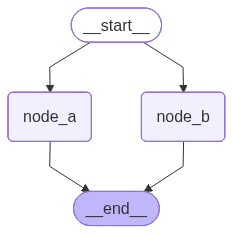

============================== -> interrupt_res <- ==============================
{'__interrupt__': [Interrupt(value='请输入您的姓名', id='deef56dc6aecb7a324cc8d1e96fbdd3a'), Interrupt(value='请输入您的年龄', id='5f281a3a14c909baef7796e4801d682d')]}


[StateSnapshot(values={}, next=('node_a', 'node_b'), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17c4b0-a7b4-65ac-8000-1c5e85434dd1'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-10T10:35:16.543829+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17c4b0-a7b2-6969-bfff-d5356293d062'}}, tasks=(PregelTask(id='c8b07c43-e9c0-c7d8-d71b-bf9f1d31b658', name='node_a', path=('__pregel_pull', 'node_a'), error=None, interrupts=(Interrupt(value='请输入您的姓名', id='deef56dc6aecb7a324cc8d1e96fbdd3a'),), state=None, result=None), PregelTask(id='499d8c3e-f31b-70ee-2744-7937e3402685', name='node_b', path=('__pregel_pull', 'node_b'), error=None, interrupts=(Interrupt(value='请输入您的年龄', id='5f281a3a14c909baef7796e4801d682d'),), state=None, result=None)), interrupts=(Interrupt(value='请输入您的姓名', id='deef56dc6aecb7a324cc8d1e96fbdd3a'), Interrupt(value='请输入您的年龄', id='5f281a3a14c909baef7796e480

In [1]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

class OverAllState(TypedDict):
    username: str
    age: int

def node_a(state: OverAllState) -> OverAllState:
    username = interrupt("请输入您的姓名")
    return {
        "username": username
    }

def node_b(state: OverAllState) -> OverAllState:
    age = interrupt("请输入您的年龄")
    return {
        "age": age
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_edge(START, "node_a")
builder.add_edge(START, "node_b")
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "123"}}
interrupted_res = graph.invoke({}, config=config)
print('=' * 30, '-> interrupt_res <-', '=' * 30)
print(interrupted_res)

list(graph.get_state_history(config=config))

In [2]:
# 6. 恢复执行
resume_map = {}
for i in interrupted_res['__interrupt__']:
    user_input = input(f"{i.value}:")
    if "年龄" in i.value:
        resume_map[i.id] = int(user_input)
    else:
        resume_map[i.id] = user_input

resumed_res = graph.invoke(Command(resume=resume_map),config=config)
print(resumed_res)

{'username': '小王', 'age': 18}


In [3]:
list(graph.get_state_history(config=config))

[StateSnapshot(values={'username': '小王', 'age': 18}, next=(), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17c4b6-9b3f-6ce6-8001-cf97debeb625'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-10T10:37:56.299069+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17c4b0-a7b4-65ac-8000-1c5e85434dd1'}}, tasks=(), interrupts=()),
 StateSnapshot(values={}, next=('node_a', 'node_b'), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17c4b0-a7b4-65ac-8000-1c5e85434dd1'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-10T10:35:16.543829+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17c4b0-a7b2-6969-bfff-d5356293d062'}}, tasks=(PregelTask(id='c8b07c43-e9c0-c7d8-d71b-bf9f1d31b658', name='node_a', path=('__pregel_pull', 'node_a'), error=None, interrupts=(Interru